In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train_data = pd.read_csv("/kaggle/input/titanic/train.csv") #load train data from train.csv file
test_data = pd.read_csv("/kaggle/input/titanic/test.csv") #load test data from test.csv file
print("train_data_shape =", train_data.shape,'\n',"test_data_shape =" ,test_data.shape) #number of rows and columns
train_data.head() #have a look at first 5 rows of train_data table

train_data_shape = (891, 12) 
 test_data_shape = (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


[None]

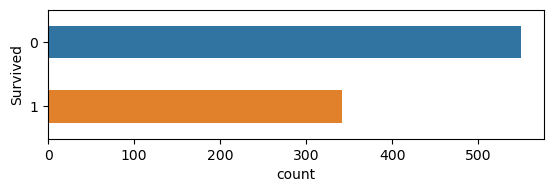

In [3]:
sns.countplot(data = train_data, y='Survived', width=0.5).set(aspect=75) # number of passangers survived vs dead in train data

In [4]:
train_data.info() # summary of train data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Comments:
* 177 missing values in "Age" column
* 2 missing values in "Embarked" column
* 687 missing values in "Cabin" column
* "Pclass","Embarked","Sex" colums can be categorical

In [5]:
# Corrected "Pclass","Embarked","Sex" datatypes
train_data[["Pclass","Embarked","Sex"]] = train_data[["Pclass","Embarked","Sex"]].astype('category')
test_data[["Pclass","Embarked","Sex"]] = test_data[["Pclass","Embarked","Sex"]].astype('category')

[Text(0, 0.5, '')]

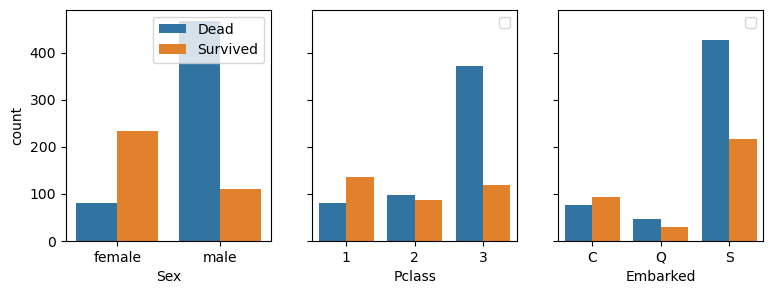

In [6]:
fig, (ax0, ax1, ax2) = plt.subplots(nrows=1, ncols=3, sharey=True)
fig.set_size_inches([9,3])
sns.countplot(x="Sex", hue='Survived',data=train_data, ax=ax0).legend(["Dead","Survived"])
sns.countplot(x="Pclass", hue='Survived',data=train_data, ax=ax1).legend(''); ax1.set(ylabel='')
sns.countplot(x="Embarked", hue='Survived',data=train_data, ax=ax2).legend(''); ax2.set(ylabel='')

Comments:
* Dead rate for Pclass3 is higher.
* Higher death rate for passangers embarked at Southampton
* There is a higher death rate for men compared to women.

<Axes: xlabel='Survived', ylabel='Age'>

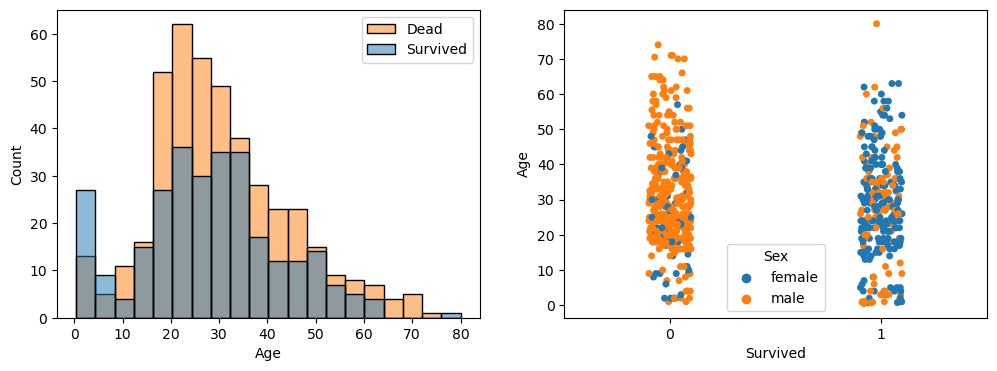

In [7]:
fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2)
fig.set_size_inches([12,4])
sns.histplot(x="Age", hue= "Survived", hue_order = [1,0], data =train_data, ax=ax0).legend(["Dead","Survived"])
sns.stripplot(y="Age", x= "Survived", hue="Sex", ax=ax1,data =train_data)
#sns.histplot(x="Fare", hue= "Survived", hue_order = [1,0], data =train_data, bins=20, ax=ax1).legend(["Dead","Survived"])

Comments:
* Survived rate is highest in 0-10 age and lowest in 65+
* Most of the passenger fares are under $50. Those who can afford more than $50 are more likely to survive

In [8]:
test_data.info() # summary of test data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  418 non-null    int64   
 1   Pclass       418 non-null    category
 2   Name         418 non-null    object  
 3   Sex          418 non-null    category
 4   Age          332 non-null    float64 
 5   SibSp        418 non-null    int64   
 6   Parch        418 non-null    int64   
 7   Ticket       418 non-null    object  
 8   Fare         417 non-null    float64 
 9   Cabin        91 non-null     object  
 10  Embarked     418 non-null    category
dtypes: category(3), float64(2), int64(3), object(3)
memory usage: 27.9+ KB


* 1 missing value in "Fare" 
* 86 missing values in "Age"

Comment:
* Regression model does not work as we have NaN values in the dataset so i select columns with nonmissing values as features.
* Convert categorical variable into dummy/indicator variables. Such as Men =1 Female = 0 if the passanger is a man.
* 'Sex_female','Pclass_3','Embarked_Q' columns are dropped. For ex. sex_male = 1 have the same meaning sex_female=0 so we dont need sex_female column.

In [9]:
Y_train = train_data["Survived"]
features = ["Fare","Pclass", "Sex", "SibSp", "Parch", "Embarked"]
X_train = pd.get_dummies(train_data[features]) #Convert categorical variable into dummy/indicator variables.
X_train.drop(columns=['Sex_female','Pclass_3','Embarked_Q'], inplace = True)
X_test = pd.get_dummies(test_data[features]) #Convert categorical variable into dummy/indicator variables.
X_test.drop(columns=['Sex_female','Pclass_3','Embarked_Q'], inplace = True)
X_test["Fare"].iloc[152] = test_data["Fare"].mean() # filled 1 null value with mean value of Fare because linear model does not work with missing values
X_test.head()

/tmp/ipykernel_20/1629491981.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test["Fare"].iloc[152] = test_data["Fare"].mean() # filled 1 null value with mean value of Fare because linear model does not work with missing values


,Fare,SibSp,Parch,Pclass_1,Pclass_2,Sex_male,Embarked_C,Embarked_S
0,7.8292,0,0,0,0,1,0,0
1,7.0000,1,0,0,0,0,0,1
2,9.6875,0,0,0,1,1,0,0
3,8.6625,0,0,0,0,1,0,1
4,12.2875,1,1,0,0,0,0,1


In [10]:
from sklearn.model_selection import train_test_split
X_trainv, X_valid, Y_trainv, Y_valid = train_test_split(X_train, Y_train, test_size=0.2, random_state=5)
print("X_trainv_size =", X_trainv.shape, '\n', "X_valid_size =", X_valid.shape)

X_trainv_size = (712, 8) 
 X_valid_size = (179, 8)


In [11]:
from sklearn import preprocessing
scaler = preprocessing.StandardScaler()
scaler.fit(X_trainv)
X_trainStd = scaler.transform(X_trainv)
X_testStandard = scaler.transform(X_valid)

In [12]:
from sklearn.svm import SVC
model = SVC(C=1,kernel='linear')
model.fit(X_trainStd,Y_trainv)
predictions = model.predict(X_valid)
model.score(X_testStandard, Y_valid)

/opt/conda/lib/python3.10/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


0.7932960893854749

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
pipe=Pipeline([('scaler',preprocessing.StandardScaler()),('Classifier',SVC())])
tuned_parameters = [{'Classifier__kernel': ['rbf'], 
                     'Classifier__gamma': [1,0.1,0.01,0.001],
                     'Classifier__C': [1, 10, 100]},
                    {'Classifier__kernel': ['linear'], 'Classifier__C': [1, 10, 100]},
                   {'Classifier__kernel':['poly'], 'Classifier__C':[1, 10]}]
grid = GridSearchCV(pipe,tuned_parameters,refit=True,verbose=2, cv=5, scoring='accuracy')
grid.fit(X_trainv,Y_trainv)

Fitting 5 folds for each of 17 candidates, totalling 85 fits
[CV] END Classifier__C=1, Classifier__gamma=1, Classifier__kernel=rbf; total time=   0.0s
[CV] END Classifier__C=1, Classifier__gamma=1, Classifier__kernel=rbf; total time=   0.0s
[CV] END Classifier__C=1, Classifier__gamma=1, Classifier__kernel=rbf; total time=   0.0s
[CV] END Classifier__C=1, Classifier__gamma=1, Classifier__kernel=rbf; total time=   0.0s
[CV] END Classifier__C=1, Classifier__gamma=1, Classifier__kernel=rbf; total time=   0.0s
[CV] END Classifier__C=1, Classifier__gamma=0.1, Classifier__kernel=rbf; total time=   0.0s
[CV] END Classifier__C=1, Classifier__gamma=0.1, Classifier__kernel=rbf; total time=   0.0s
[CV] END Classifier__C=1, Classifier__gamma=0.1, Classifier__kernel=rbf; total time=   0.0s
[CV] END Classifier__C=1, Classifier__gamma=0.1, Classifier__kernel=rbf; total time=   0.0s
[CV] END Classifier__C=1, Classifier__gamma=0.1, Classifier__kernel=rbf; total time=   0.0s
[CV] END Classifier__C=1, Cla

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('Classifier', SVC())]),
             param_grid=[{'Classifier__C': [1, 10, 100],
                          'Classifier__gamma': [1, 0.1, 0.01, 0.001],
                          'Classifier__kernel': ['rbf']},
                         {'Classifier__C': [1, 10, 100],
                          'Classifier__kernel': ['linear']},
                         {'Classifier__C': [1, 10],
                          'Classifier__kernel': ['poly']}],
             scoring='accuracy', verbose=2)

In [14]:
print(grid.best_params_)

{'Classifier__C': 10, 'Classifier__gamma': 0.01, 'Classifier__kernel': 'rbf'}


In [15]:
scaler.fit(X_trainv)
X_trainStd = scaler.transform(X_trainv)
X_testStd = scaler.transform(X_valid)

In [16]:
model = SVC(C=10,gamma=0.01,kernel='rbf')
model.fit(X_trainStd,Y_trainv)
predictions = model.predict(X_testStd)
model.score(X_testStd, Y_valid)

0.8156424581005587

In [17]:
scaler.fit(X_train)
X_trainStd = scaler.transform(X_train)
X_testStd = scaler.transform(X_test)

In [18]:
model = SVC(C=10,gamma=0.01,kernel='rbf')
model.fit(X_trainStd,Y_train)
predictions = model.predict(X_testStd)

In [19]:
output = pd.DataFrame({'PassengerId': test_data.PassengerId, 'Survived': predictions})
output.to_csv('submission.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!
